# Enviroment setup


```bash
conda remove -n ts2vec --all -y
conda create -n ts2vec python=3.10 -y
conda activate ts2vec

conda install \
  pytorch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 pytorch-cuda=12.1 \
  anaconda::mkl=2023.1.0 anaconda::intel-openmp=2023.1.0 \
  -c pytorch -c nvidia -c anaconda -y

pip install numpy scipy pandas scikit-learn statsmodels bottleneck
```

Quick validation:

```bash
conda run -n ts2vec python -c "import torch; print(torch.__version__, torch.version.cuda); print(torch.cuda.is_available())"
```

# Similarity protocol for real vs synthetic IMU

This notebook implements the evaluation protocol using the code in `evaluation/similarity_protocol.py`.

Implemented metrics:

- C-FID, JS and MMD in TS2Vec embedding space;
- DTW in RTR / RTS / STS scenarios;
- discriminative score with MLP;
- predictive score with GRU;
- Pearson correlation in data space.

The notebook keeps only configuration, execution and visualization. All logic stays in Python modules.

In [1]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "pose_module").exists() and (candidate / "output").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the project root. Open the notebook inside the IMUGPT repository.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import evaluation.similarity_protocol as protocol_module
import evaluation.tsne as tsne_module

protocol_module = importlib.reload(protocol_module)
tsne_module = importlib.reload(tsne_module)

get_shared_sensor_names = protocol_module.get_shared_sensor_names
load_protocol_capture_table = protocol_module.load_protocol_capture_table
run_similarity_protocol = protocol_module.run_similarity_protocol

run_frequency_domain_tsne_all_captures = tsne_module.run_frequency_domain_tsne_all_captures

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

## Data loading

Use the filters below to restrict the exported captures before running the protocol.

In [2]:
OUTPUT_ROOT = PROJECT_ROOT / "output" / "robot_emotions_virtual_imu_v2_all_dataset"
CAPTURES_DF = load_protocol_capture_table(OUTPUT_ROOT)

CAPTURE_DOMAINS = None  # e.g. ["10ms"]
CAPTURE_USERS = None  # e.g. [2, 4]
CAPTURE_TAGS = None  # e.g. [1, 5, 9]

FILTERED_CAPTURES_DF = CAPTURES_DF.copy()
if CAPTURE_DOMAINS is not None:
    FILTERED_CAPTURES_DF = FILTERED_CAPTURES_DF[FILTERED_CAPTURES_DF["domain"].astype(str).isin([str(value) for value in CAPTURE_DOMAINS])].copy()
if CAPTURE_USERS is not None:
    FILTERED_CAPTURES_DF = FILTERED_CAPTURES_DF[FILTERED_CAPTURES_DF["user_id"].astype(int).isin([int(value) for value in CAPTURE_USERS])].copy()
if CAPTURE_TAGS is not None:
    FILTERED_CAPTURES_DF = FILTERED_CAPTURES_DF[FILTERED_CAPTURES_DF["tag_number"].astype(int).isin([int(value) for value in CAPTURE_TAGS])].copy()

display(FILTERED_CAPTURES_DF.head())
print(f"Num captures after filter: {len(FILTERED_CAPTURES_DF)}")
print("Shared sensors across all selected captures:", get_shared_sensor_names(FILTERED_CAPTURES_DF))

,clip_id,domain,user_id,tag_number,take_id,clip_dir,pose_dir,emotion,modality,stimulus,stimulus_details,protocol_tag_10ms,protocol_tag_30ms
0,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Neutrality,Standing,None,None,1.0,1
1,robot_emotions_10ms_u02_tag05,10ms,2,5,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Sadness,Sitting,Visual methods,Show/have the participant choose sad video clips,5.0,7
2,robot_emotions_10ms_u02_tag06,10ms,2,6,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Sadness,Sitting,Autobiographical recall,Ask the participant to remember a sad episode,6.0,8
3,robot_emotions_10ms_u02_tag07,10ms,2,7,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Sadness,Standing,Autobiographical recall,Ask the participant to remember a sad episode,7.0,17
4,robot_emotions_10ms_u02_tag09,10ms,2,9,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Happiness,Sitting,Visual methods,Show/have the participant choose happy video c...,9.0,5


Num captures after filter: 89
Shared sensors across all selected captures: ['waist', 'head', 'left_forearm', 'right_forearm']


## Protocol configuration

Important note: when `EMBEDDER_TRAIN_FRACTION > 0`, TS2Vec is trained only on real windows from held-out training captures, and all protocol metrics are computed on the evaluation captures.

In [3]:
SIGNAL_GROUPS = ("acc",)  # ("acc",), ("gyro",) or ("acc", "gyro")
SELECTED_SENSORS = ["right_forearm", "left_forearm"]  # None for all shared sensors
SELECTED_AXES = ("x", "y", "z")

WINDOW_TYPE = "seconds"  # "seconds" or "n_samples"
WINDOW_SIZE = None  # used only when WINDOW_TYPE == "n_samples"
WINDOW_DURATION_SEC = 3.0  # used only when WINDOW_TYPE == "seconds"

STRIDE_OR_OVERLAP_MODE = "overlap"  # "stride" or "overlap"
STRIDE = None  # used only when STRIDE_OR_OVERLAP_MODE == "stride" and WINDOW_TYPE == "n_samples"
STRIDE_SEC = None  # used only when STRIDE_OR_OVERLAP_MODE == "stride" and WINDOW_TYPE == "seconds"
OVERLAP = 0.5

RESAMPLE_METHOD = "resample_poly"
MAX_WINDOWS_PER_CAPTURE = None  # set an int to speed up exploratory runs
MAX_SAMPLES_PER_GROUP = None  # set an int to cap windows per metric group

BOOTSTRAP_ITERATIONS = 500
BOOTSTRAP_SAMPLE_SIZE = 256
JS_BINS = 32
DTW_PAIRS = 64
DTW_BAND_RADIUS = None
CV_FOLDS = 10
RANDOM_STATE = 42

EMBEDDER_TRAIN_FRACTION = 0.3  # 0.0 uses all real windows for training and evaluation (more practical, but leakage-prone)
EMBEDDER_RARE_CLASS_THRESHOLD = 1

TS2VEC_ENV_NAME = "ts2vec"
TS2VEC_REPR_DIMS = 64
TS2VEC_HIDDEN_DIMS = 64
TS2VEC_DEPTH = 8
TS2VEC_BATCH_SIZE = 16
TS2VEC_N_ITERS = 200
TS2VEC_DEVICE = "cuda"  # "cpu" or "auto"

GRU_HIDDEN_SIZE = 64
GRU_NUM_LAYERS = 1
GRU_DROPOUT = 0.0
GRU_BATCH_SIZE = 64
GRU_EPOCHS = 20
GRU_LEARNING_RATE = 1e-3
GRU_WEIGHT_DECAY = 1e-4
GRU_PATIENCE = 4

Epoch #0: loss=4.647579839355068
Epoch #1: loss=2.048346444180137


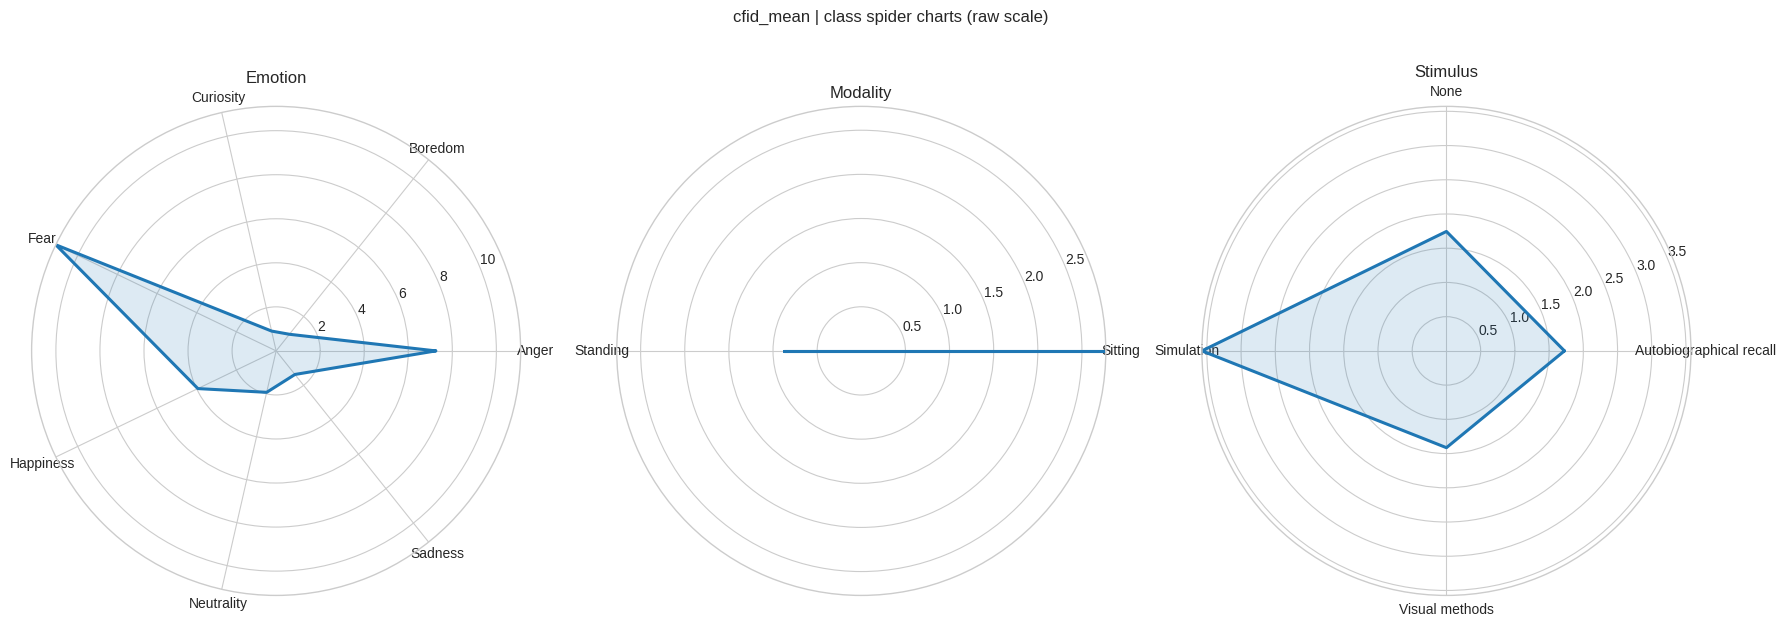

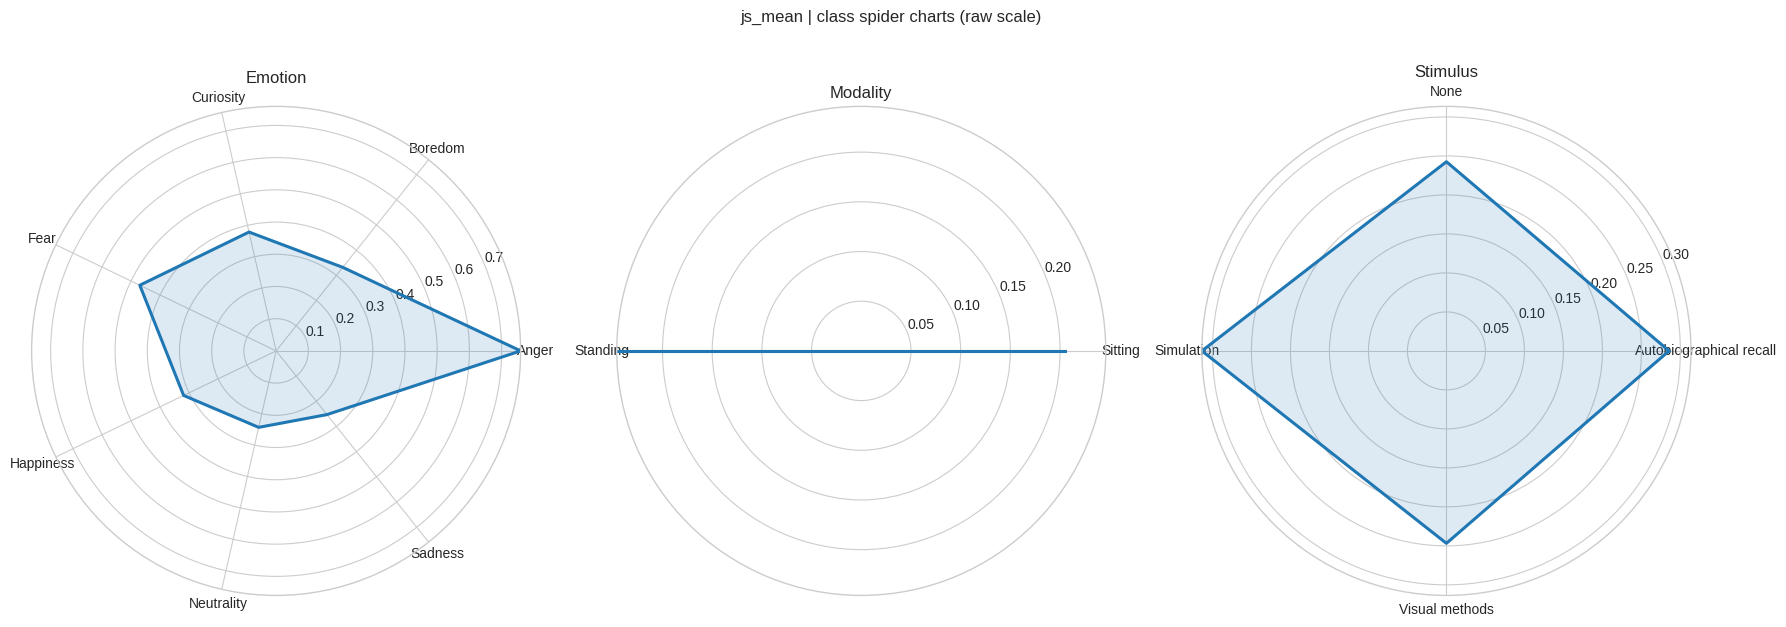

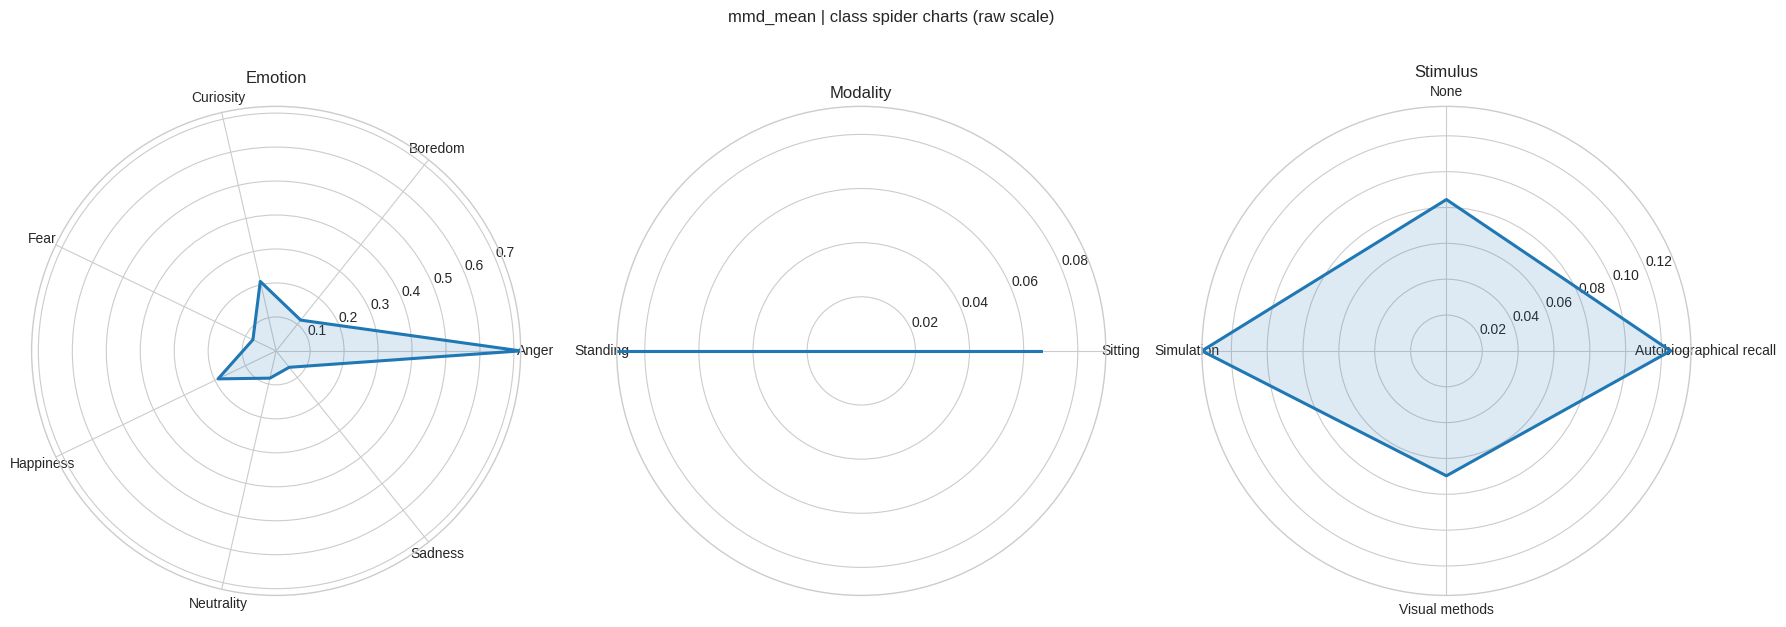

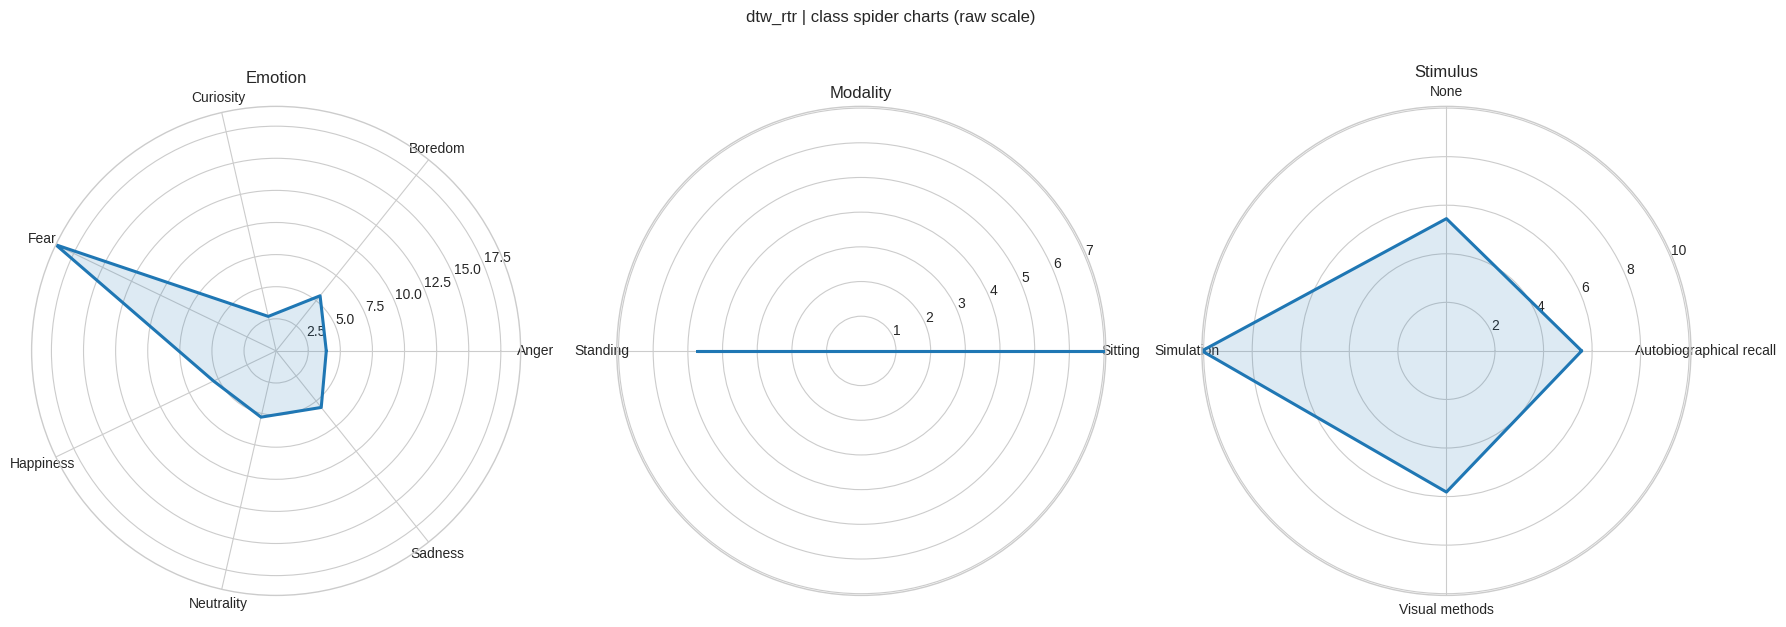

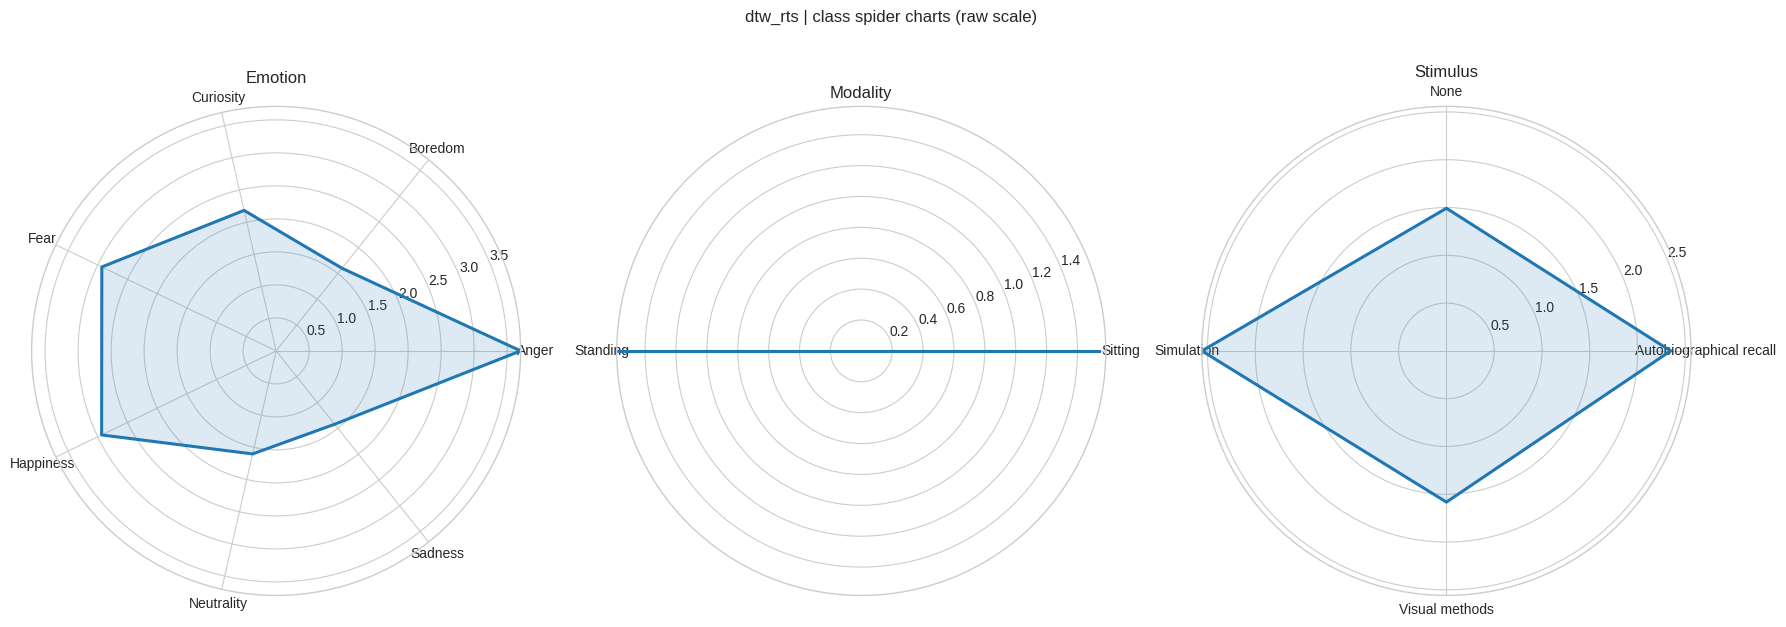

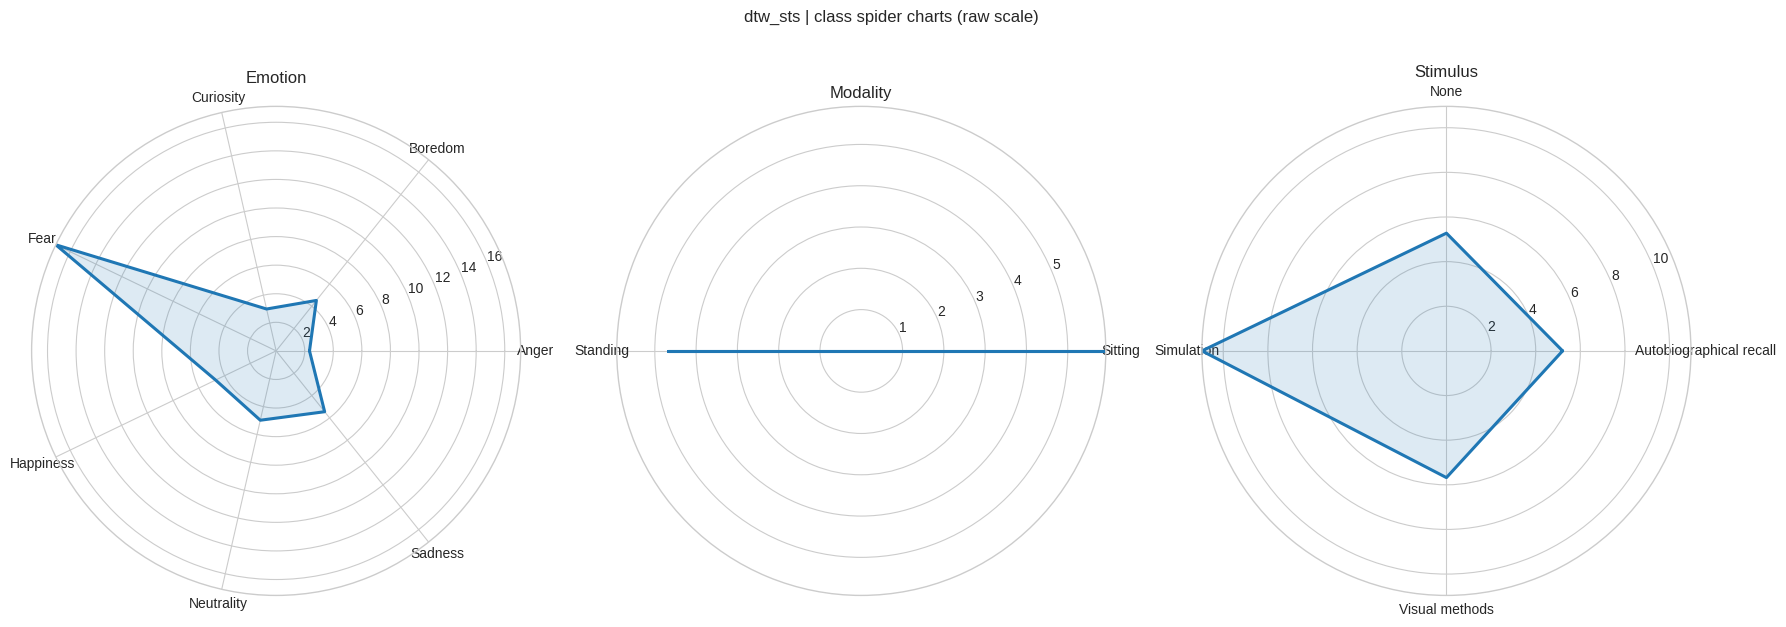

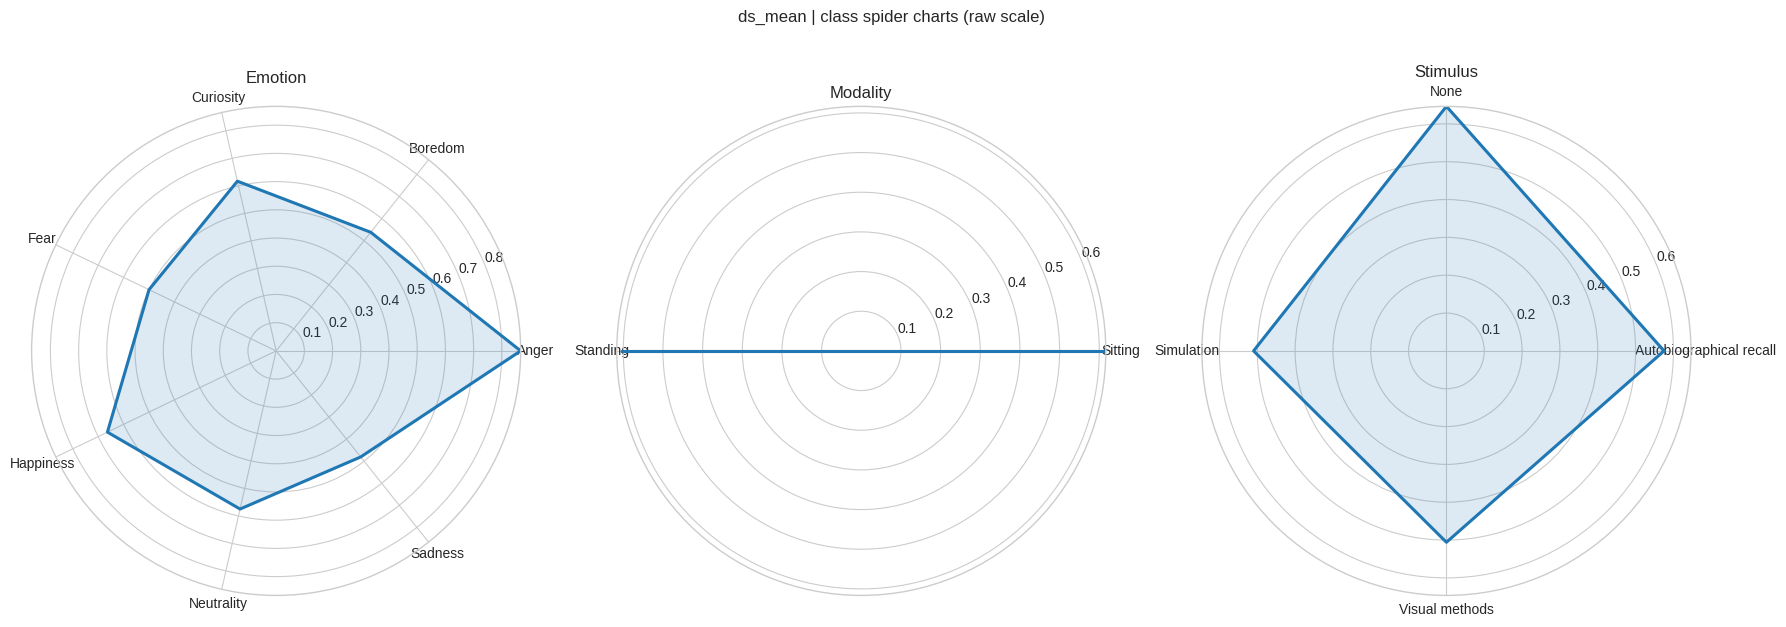

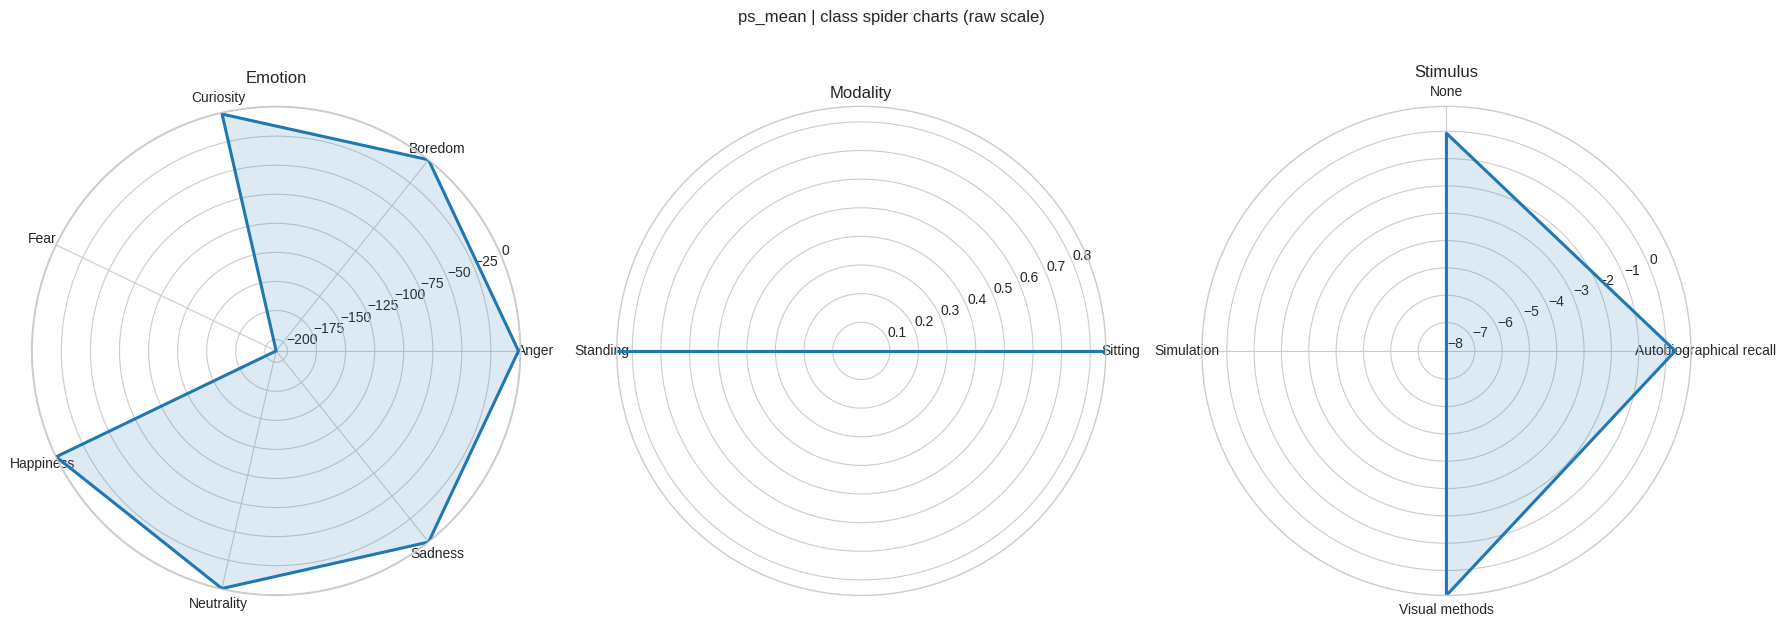

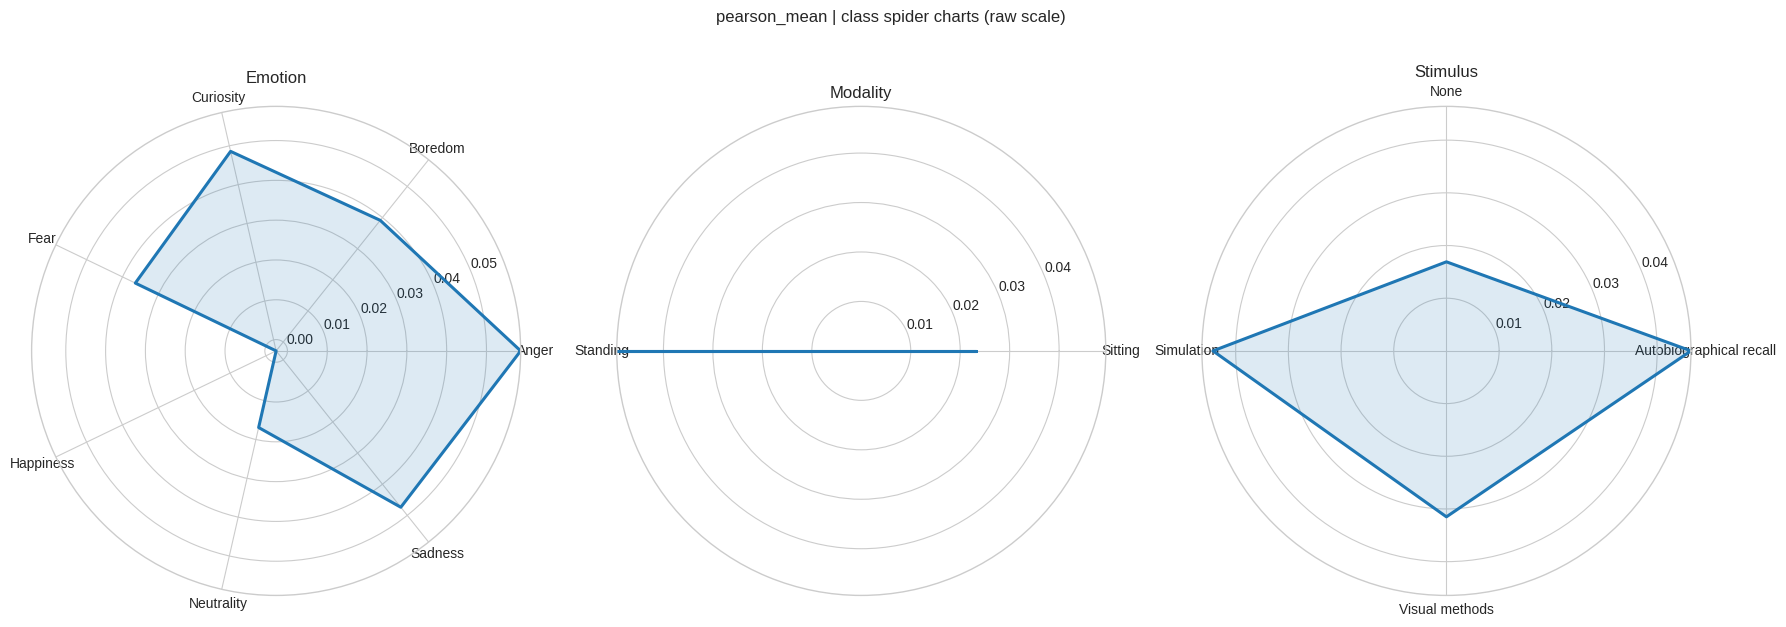

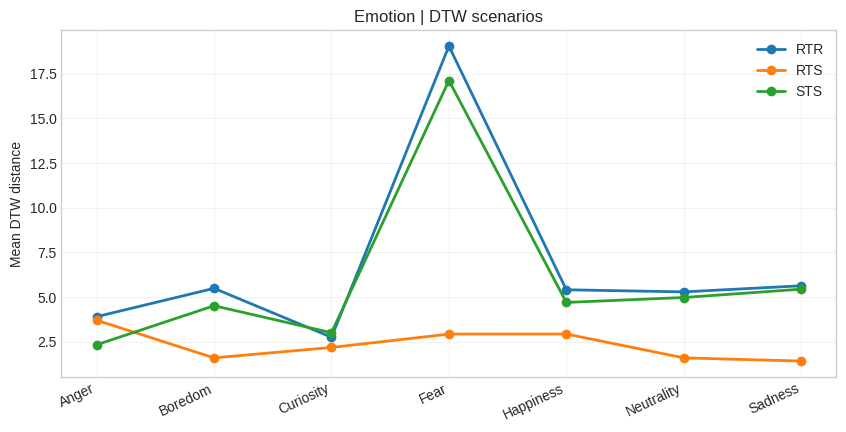

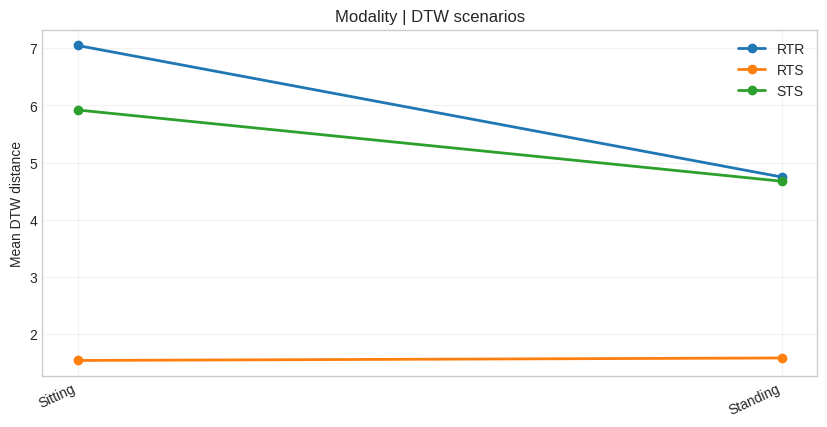

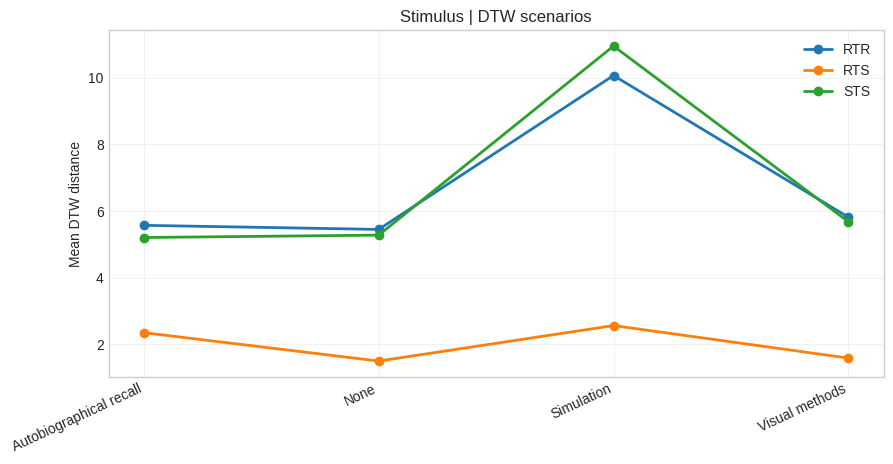

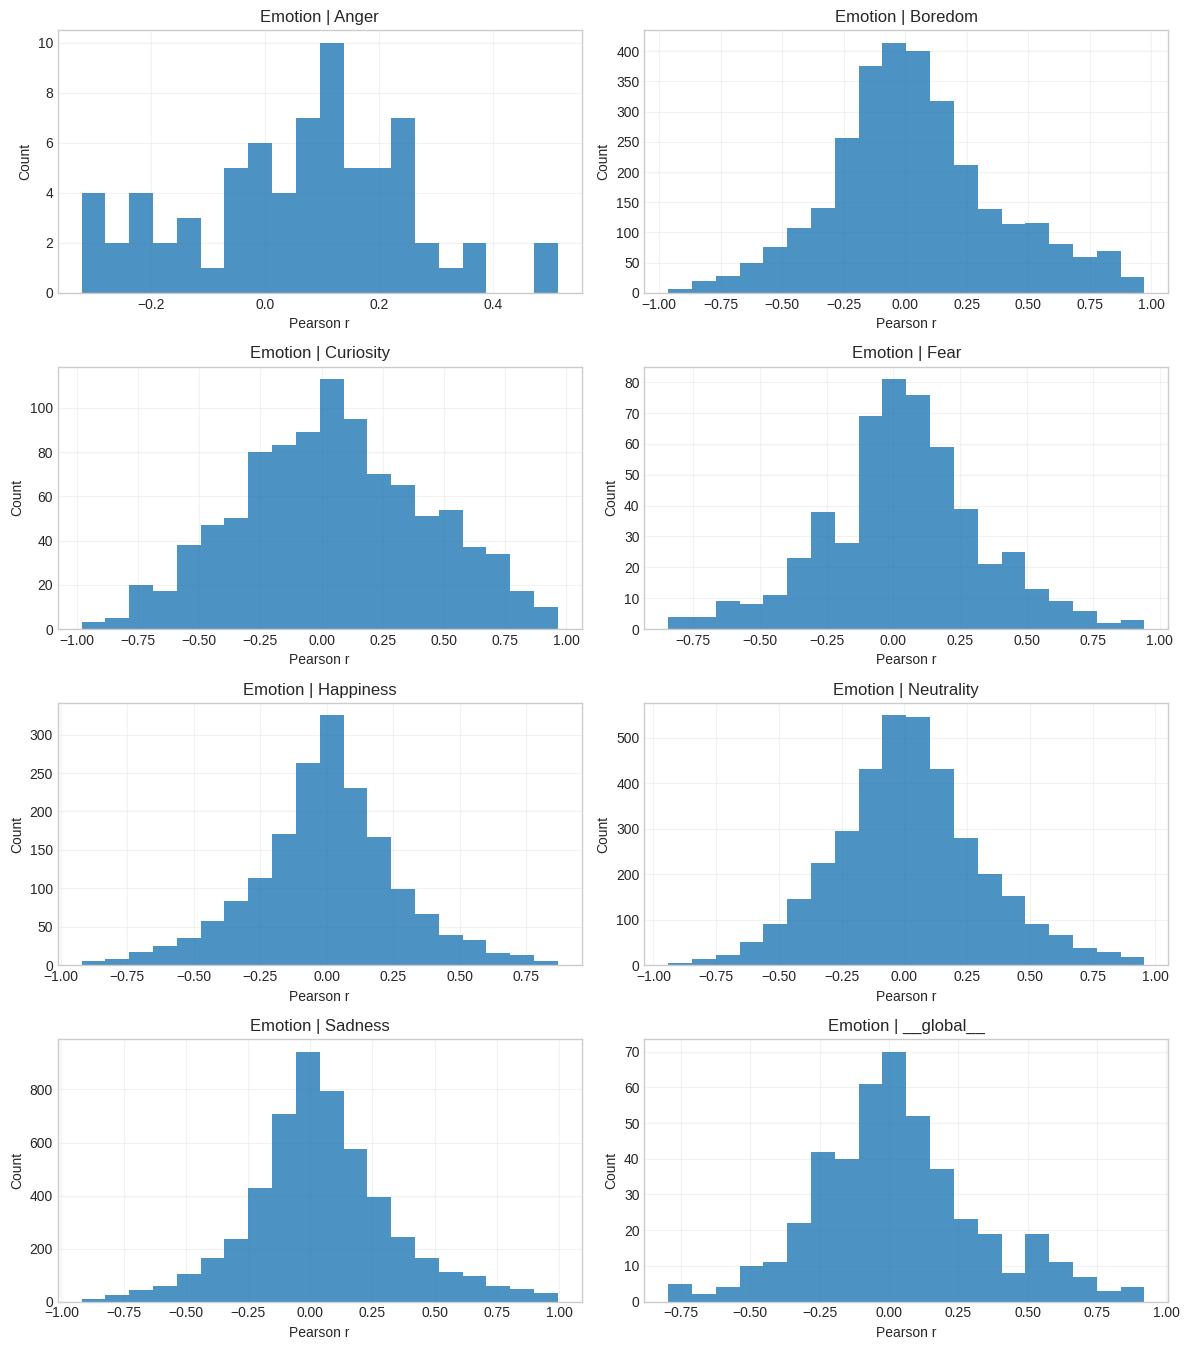

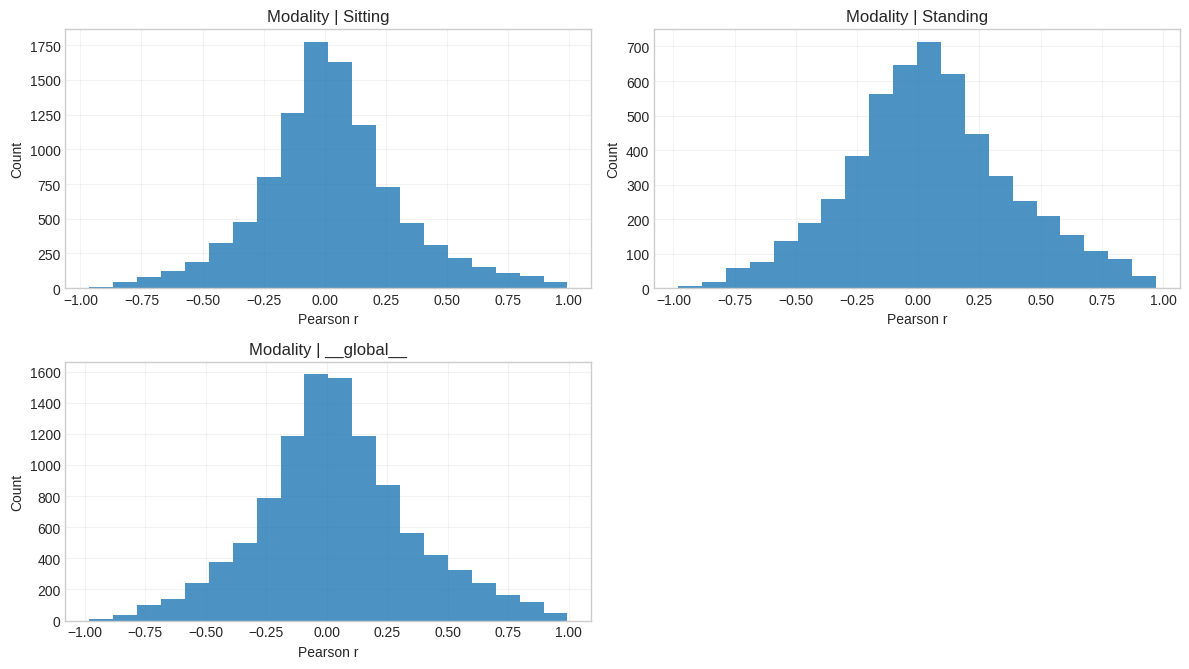

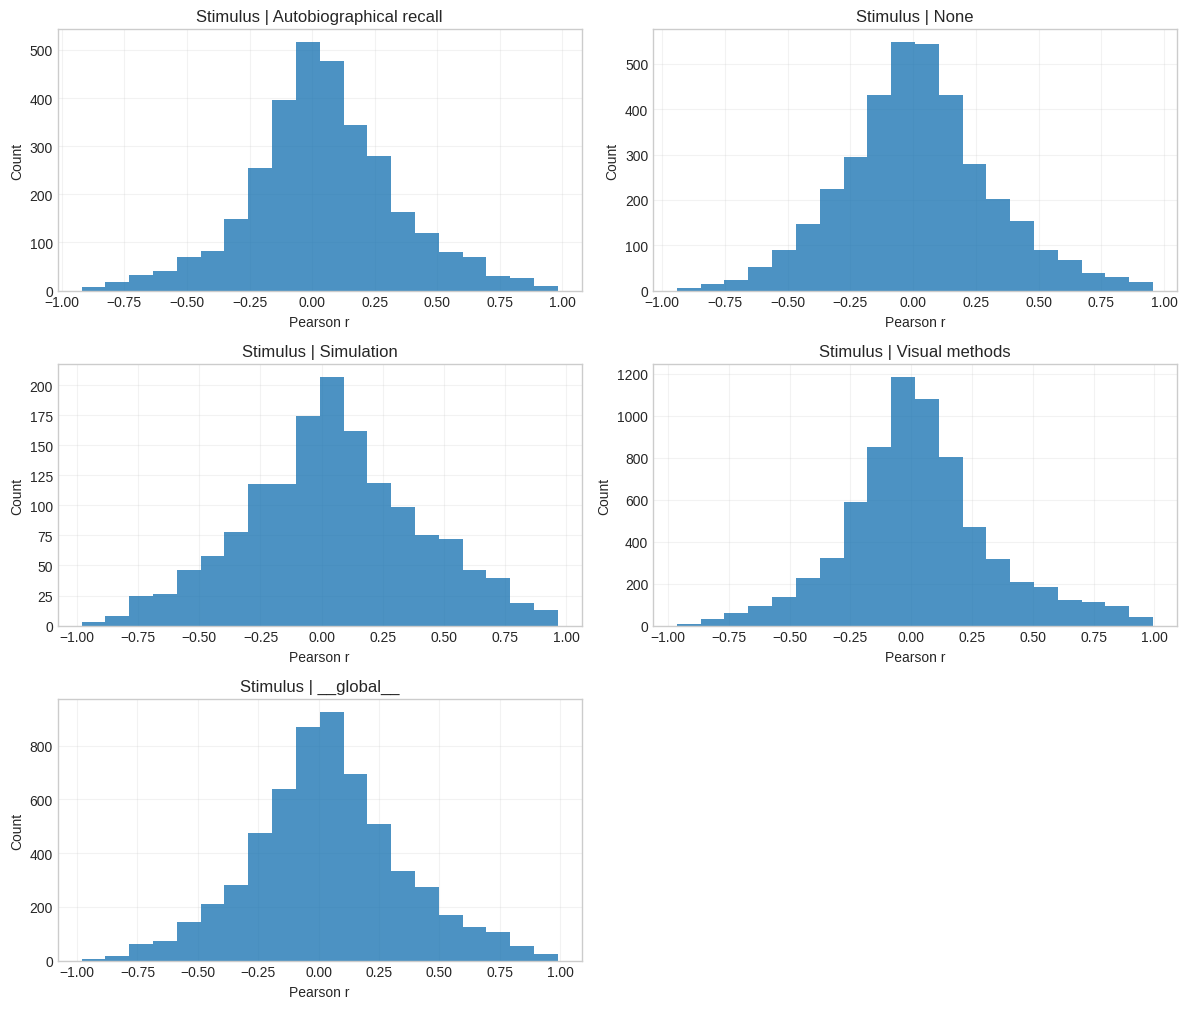

In [4]:
PROTOCOL_RESULT = run_similarity_protocol(
    captures_df=FILTERED_CAPTURES_DF,
    signal_groups=SIGNAL_GROUPS,
    selected_sensors=SELECTED_SENSORS,
    selected_axes=SELECTED_AXES,
    resample_method=RESAMPLE_METHOD,
    window_type=WINDOW_TYPE,
    window_size=WINDOW_SIZE,
    window_duration_sec=WINDOW_DURATION_SEC,
    stride_or_overlap_mode=STRIDE_OR_OVERLAP_MODE,
    stride=STRIDE,
    stride_sec=STRIDE_SEC,
    overlap=OVERLAP,
    max_windows_per_capture=MAX_WINDOWS_PER_CAPTURE,
    max_samples_per_group=MAX_SAMPLES_PER_GROUP,
    bootstrap_iterations=BOOTSTRAP_ITERATIONS,
    bootstrap_sample_size=BOOTSTRAP_SAMPLE_SIZE,
    js_bins=JS_BINS,
    dtw_pairs=DTW_PAIRS,
    dtw_band_radius=DTW_BAND_RADIUS,
    cv_folds=CV_FOLDS,
    embedder_train_fraction=EMBEDDER_TRAIN_FRACTION,
    embedder_rare_class_threshold=EMBEDDER_RARE_CLASS_THRESHOLD,
    ts2vec_env_name=TS2VEC_ENV_NAME,
    ts2vec_repr_dims=TS2VEC_REPR_DIMS,
    ts2vec_hidden_dims=TS2VEC_HIDDEN_DIMS,
    ts2vec_depth=TS2VEC_DEPTH,
    ts2vec_batch_size=TS2VEC_BATCH_SIZE,
    ts2vec_n_iters=TS2VEC_N_ITERS,
    ts2vec_device=TS2VEC_DEVICE,
    gru_hidden_size=GRU_HIDDEN_SIZE,
    gru_num_layers=GRU_NUM_LAYERS,
    gru_dropout=GRU_DROPOUT,
    gru_batch_size=GRU_BATCH_SIZE,
    gru_epochs=GRU_EPOCHS,
    gru_learning_rate=GRU_LEARNING_RATE,
    gru_weight_decay=GRU_WEIGHT_DECAY,
    gru_patience=GRU_PATIENCE,
    random_state=RANDOM_STATE,
    verbose=True,
)

## Tables

The main result table is `PROTOCOL_RESULT["results_df"]`. It contains one row for each per-class group plus balanced category-level globals.

In [5]:
display(PROTOCOL_RESULT["split_summary_df"])
display(PROTOCOL_RESULT["window_summary_df"])
display(PROTOCOL_RESULT["group_summary_df"])
display(PROTOCOL_RESULT["results_df"])

warning_rows = PROTOCOL_RESULT["results_df"][PROTOCOL_RESULT["results_df"]["warnings"].notna()].copy()
if not warning_rows.empty:
    display(warning_rows[["group_key", "warnings"]])

,embedder_split_strategy,train_fraction,num_train_captures,num_eval_captures,num_train_windows,num_eval_windows,protected_eval_captures,note
0,capture_holdout,0.3,27,62,1225,2883,1,TS2Vec is trained only on real windows from th...


,num_captures_total,num_captures_eval,num_windows_total,num_windows_eval,selected_sensors,channel_labels,ts2vec_repr_dims,bootstrap_iterations,cv_folds
0,89,62,4108,2883,"right_forearm, left_forearm","acc_x, acc_y, acc_z",64,500,10


,group_key,class_category,class_value,num_pairs,num_captures
0,overall::all,overall,all,2883,62
1,emotion::Anger,emotion,Anger,12,1
2,emotion::Boredom,emotion,Boredom,572,12
3,emotion::Curiosity,emotion,Curiosity,197,5
4,emotion::Fear,emotion,Fear,88,2
5,emotion::Happiness,emotion,Happiness,403,10
6,emotion::Neutrality,emotion,Neutrality,687,15
7,emotion::Sadness,emotion,Sadness,924,17
8,emotion::__global__,emotion,__global__,84,40
9,modality::Sitting,modality,Sitting,1905,38


,group_key,class_category,class_value,num_pairs,num_captures,cfid_mean,cfid_std,cfid_num_bootstrap,js_mean,js_std,js_num_bootstrap,mmd_mean,mmd_std,mmd_num_bootstrap,dtw_rtr,dtw_rts,dtw_sts,ds_mean,ds_std,ds_num_splits,ds_cv_strategy,ps_mean,ps_std,ps_mae_mean,ps_mae_std,ps_metric_name,ps_num_splits,ps_cv_strategy,pearson_mean,pearson_std,warnings
0,overall::all,overall,all,2883,62,2.425274,1.392257,500,0.187563,0.008310,500,0.058649,0.018179,500,7.569247,2.364928,5.588324,0.600084,0.060699,10,group,0.894285,0.133221,0.132343,0.203454,r2,10,group,0.032326,0.159199,None
1,emotion::Anger,emotion,Anger,12,1,7.247233,0.784139,500,0.759159,0.010426,500,0.719871,0.043493,500,3.905568,3.704692,2.334927,0.866667,0.219427,10,window,-1.281578,1.232623,3.021915,0.621492,r2,10,window,0.058587,0.092475,None
2,emotion::Boredom,emotion,Boredom,572,12,0.965282,0.178843,500,0.331777,0.009230,500,0.115869,0.013252,500,5.490187,1.601133,4.516891,0.537734,0.089029,10,group,0.516729,0.635185,0.208772,0.155292,r2,10,group,0.039108,0.198410,None
3,emotion::Curiosity,emotion,Curiosity,197,5,0.922890,0.107808,500,0.378438,0.007635,500,0.209725,0.017771,500,2.754334,2.183222,3.006797,0.616934,0.175239,5,group,-0.808224,1.695644,0.624099,0.282078,r2,5,group,0.048572,0.184695,None
4,emotion::Fear,emotion,Fear,88,2,11.103122,4.438100,500,0.469784,0.013336,500,0.075875,0.065794,500,19.042856,2.931108,17.113098,0.500000,0.000000,2,group,-209.734830,258.670230,9.269382,3.171687,r2,2,group,0.036422,0.161116,None
5,emotion::Happiness,emotion,Happiness,403,10,3.944286,0.876346,500,0.318799,0.010377,500,0.189748,0.013734,500,5.409145,2.934527,4.701883,0.663653,0.212045,10,group,0.265120,0.293687,0.410909,0.198136,r2,10,group,-0.002839,0.127894,None
6,emotion::Neutrality,emotion,Neutrality,687,15,1.929772,1.093351,500,0.243520,0.022177,500,0.082351,0.023008,500,5.292151,1.601265,4.977520,0.574929,0.111706,10,group,-0.072006,1.466568,0.196941,0.138385,r2,10,group,0.016905,0.139331,None
7,emotion::Sadness,emotion,Sadness,924,17,1.369322,0.924368,500,0.253016,0.021368,500,0.061816,0.019767,500,5.633199,1.421578,5.444645,0.480752,0.100610,10,group,0.595753,0.811739,0.127314,0.053251,r2,10,group,0.047396,0.149362,None
8,emotion::__global__,emotion,__global__,84,40,5.958887,4.686402,500,0.357333,0.014069,500,0.114038,0.033781,500,10.043139,2.194322,8.184713,0.596406,0.103334,10,group,-0.911784,1.318056,0.734311,0.978870,r2,10,group,0.030130,0.171042,None
9,modality::Sitting,modality,Sitting,1905,38,2.770357,1.592635,500,0.205245,0.009273,500,0.066427,0.019724,500,7.049860,1.540122,5.921604,0.616460,0.057915,10,group,0.854224,0.172699,0.184631,0.325712,r2,10,group,0.023291,0.147503,None


In [6]:
print(json.dumps(PROTOCOL_RESULT["protocol_records"][:3], indent=2, ensure_ascii=False))

[
  {
    "class_category": "overall",
    "class": "all",
    "metrics": {
      "cfid": {
        "mean": 2.425273962694498,
        "std": 1.39225723426593
      },
      "js": {
        "mean": 0.18756289062759243,
        "std": 0.008309573183989507
      },
      "mmd": {
        "mean": 0.05864913152879372,
        "std": 0.018178691637065134
      },
      "dtw": {
        "rtr": 7.569246752785695,
        "rts": 2.364928311800481,
        "sts": 5.58832420441229
      },
      "ds": {
        "mean": 0.6000839192292928,
        "std": 0.060698557618382776
      },
      "ps": {
        "mean": 0.8942851781845093,
        "std": 0.13322138399731784
      },
      "pearson": {
        "mean": 0.03232607320922442,
        "std": 0.15919937171047552
      }
    }
  },
  {
    "class_category": "emotion",
    "class": "Anger",
    "metrics": {
      "cfid": {
        "mean": 7.247232574514861,
        "std": 0.7841392241132916
      },
      "js": {
        "mean": 0.75915860441533